# INDENG 231 — Project 1: Backtesting Simulation for Trading Strategies

**Author:** Kai Chang  
**Date:** May 2026  
**Dataset:** Nasdaq-100 daily closes, 5 years (April 2021 – April 2026), 101 stocks  
**Favorite Stock:** AMGN (Amgen)

---

## Table of Contents
1. **Setup & Data Loading**
2. **Backtest Engine & Metrics**
3. **Deliverable 3** — Single-Stock Strategy Evaluation (AMGN)
4. **Deliverable 4** — Portfolio Backtesting (Uniform & Inverse-Vol Weighting)
5. **Deliverable 5** — Beat the Benchmarks


## 1. Setup & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from abc import ABC, abstractmethod
from copy import deepcopy
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

FAVORITE_STOCK = 'AMGN'
INITIAL_NAV = 1.0  # normalized
RISK_FREE_RATE = 0.0
TRADING_DAYS_PER_YEAR = 252

print('Libraries loaded successfully.')


Libraries loaded successfully.


### 1.1 Load & Prepare Data

The CSV is in long format ().  
We pivot to a wide DataFrame of shape  containing daily closing prices.


In [2]:
# Load raw data
raw = pd.read_csv('nasdaq100_daily_5y.csv', parse_dates=['date'])
print(f'Raw data shape: {raw.shape}')
print(f'Tickers: {raw["ticker"].nunique()}')
print(f'Date range: {raw["date"].min().date()} to {raw["date"].max().date()}')

# Pivot to wide format: rows = dates, columns = tickers, values = close
prices = raw.pivot(index='date', columns='ticker', values='close').sort_index()
prices = prices.ffill().bfill()  # forward-fill gaps, back-fill initial NaN for late-entry stocks

# Daily returns
returns = prices.pct_change()

TICKERS = list(prices.columns)
N_STOCKS = len(TICKERS)
print(f'\nPrice matrix: {prices.shape[0]} trading days × {N_STOCKS} stocks')
print(f'Missing values after ffill: {prices.isna().sum().sum()}')
prices.head()


Raw data shape: (124330, 7)
Tickers: 101
Date range: 2021-04-13 to 2026-04-10

Price matrix: 1255 trading days × 101 stocks
Missing values after ffill: 0


ticker,AAPL,ABNB,ADBE,ADI,ADP,ADSK,AEP,ALNY,AMAT,AMD,...,TTWO,TXN,VRSK,VRTX,WBD,WDAY,WDC,WMT,XEL,ZS
date,,,,,,,,,,,,,,,,,,,,,
2021-04-13,134.4300,177.9500,514.8600,159.1600,191.9200,295.3500,86.7200,136.2300,135.1000,80.1900,...,182.6600,191.2400,183.5700,215.9400,24.7800,265.9300,69.8000,46.4567,68.4800,196.6500
2021-04-14,132.0300,176.4300,510.6300,158.4600,191.1500,294.3500,87.0700,138.3100,134.1400,78.5500,...,181.4400,190.3300,181.9500,217.1300,24.7800,259.8500,68.6900,46.4400,68.6800,192.3900
2021-04-15,134.5000,175.3500,523.2500,160.7100,191.8900,298.8600,87.8050,139.0200,134.4100,83.0100,...,182.5000,193.1700,184.5000,221.1000,24.7800,260.2900,68.7300,46.7200,69.9600,195.9200
2021-04-16,134.1600,178.6900,525.0800,159.5100,192.9400,300.1600,88.5500,138.8800,133.7300,82.1500,...,178.8000,191.9300,185.4600,219.3900,24.7800,256.3500,68.8900,46.8700,70.3700,192.4900
2021-04-19,134.8400,174.5800,516.1700,156.9100,192.7500,290.2000,88.6500,137.4000,130.8900,81.1100,...,177.9100,187.0600,184.5300,219.1800,24.7800,254.5100,68.3100,46.5700,70.4900,190.9400


## 2. Backtest Engine & Metrics

### 2.1 Performance Metrics

All metrics are computed from the daily NAV series produced by the engine.

| Metric | Formula |
|---|---|
| Cumulative Return | $\dfrac{V_T}{V_0} - 1$ |
| Annualized Return | $\left(\dfrac{V_T}{V_0}\right)^{252/T} - 1$ |
| Annualized Volatility | $\operatorname{std}(r_t)\cdot\sqrt{252}$ |
| Sharpe Ratio | $\dfrac{\operatorname{mean}(r_t)}{\operatorname{std}(r_t)}\cdot\sqrt{252}$ |
| Max Drawdown | $\min_t \left( V_t / \max_{s \leq t} V_s - 1 \right)$ |
| Win Rate | $\Pr(r_t > 0)$, the fraction of days with positive return |


In [3]:
def compute_metrics(nav_series):
    """Compute standard performance metrics from a NAV (Net Asset Value) series."""
    daily_rets = nav_series.pct_change().dropna()
    T = len(daily_rets)
    
    cum_ret = nav_series.iloc[-1] / nav_series.iloc[0] - 1
    ann_ret = (nav_series.iloc[-1] / nav_series.iloc[0]) ** (TRADING_DAYS_PER_YEAR / T) - 1
    ann_vol = daily_rets.std() * np.sqrt(TRADING_DAYS_PER_YEAR)
    sharpe = (daily_rets.mean() / daily_rets.std() * np.sqrt(TRADING_DAYS_PER_YEAR)) if daily_rets.std() > 0 else 0.0
    
    # Max drawdown
    cummax = nav_series.cummax()
    drawdown = nav_series / cummax - 1
    max_dd = drawdown.min()
    
    win_rate = (daily_rets > 0).mean()
    
    return {
        'Cumulative Return': cum_ret,
        'Annualized Return': ann_ret,
        'Annualized Volatility': ann_vol,
        'Sharpe Ratio': sharpe,
        'Max Drawdown': max_dd,
        'Win Rate': win_rate
    }

def metrics_table(results_dict):
    """Create a formatted DataFrame comparing metrics across strategies."""
    df = pd.DataFrame(results_dict).T
    # Format
    fmt_df = df.copy()
    for col in ['Cumulative Return', 'Annualized Return', 'Annualized Volatility', 'Max Drawdown', 'Win Rate']:
        if col in fmt_df.columns:
            fmt_df[col] = fmt_df[col].map(lambda x: f'{x:.2%}')
    fmt_df['Sharpe Ratio'] = fmt_df['Sharpe Ratio'].map(lambda x: f'{float(x):.3f}')
    return fmt_df

def display_full_metrics(title, results_dict, line_width=100):
    """Render every row and column of a metrics table in notebook output."""
    table = metrics_table(results_dict)
    print(title)
    print('=' * line_width)
    display(HTML(table.to_html(escape=False)))


print('Metrics functions defined.')


Metrics functions defined.


### 2.2 Strategy Interface & Backtest Engine

**Design principles:**
- **Separation of concerns:** Strategies output target allocation vectors. The engine handles execution, accounting, and logging.
- **No lookahead:** The engine slices price history to end at the current date before calling the strategy.
- **Extensibility:** Adding a new strategy means writing one class with a  method.

**Assumptions:**
- Zero transaction costs (base case)
- Zero cash return (risk-free rate = 0)
- All trades execute at the day's closing price
- Initial NAV = 1.0 (normalized)
- Daily rebalancing


In [4]:
class BaseStrategy(ABC):
    """Abstract base class for all trading strategies."""
    
    def __init__(self, name, tickers):
        self.name = name
        self.tickers = tickers
        self.n_stocks = len(tickers)
    
    @abstractmethod
    def generate_weights(self, date, price_history):
        """
        Generate target portfolio weights.
        
        Parameters
        ----------
        date : pd.Timestamp
            Current trading day.
        price_history : pd.DataFrame
            Closing prices up to and including Mon May  4 22:47:50 UTC 2026. Shape: (days, n_stocks).
            NO future data is included.
        
        Returns
        -------
        np.ndarray of shape (n_stocks,)
            Target weights in [0, 1], sum <= 1. Remainder is cash.
        """
        pass
    
    def _validate_weights(self, weights):
        """Enforce constraints: no short selling, no leverage."""
        weights = np.maximum(weights, 0.0)  # no shorts
        total = weights.sum()
        if total > 1.0:
            weights = weights / total  # normalize to sum <= 1
        return weights


class BacktestEngine:
    """
    Daily-close backtesting engine.
    
    For each trading day:
    1. Slice price_history up to current date (no lookahead).
    2. Call strategy.generate_weights().
    3. Validate weights.
    4. Execute trades at today's close.
    5. Update NAV.
    6. Log results.
    """
    
    def __init__(self, strategy, prices, start_date=None, end_date=None, initial_nav=INITIAL_NAV):
        self.strategy = strategy
        self.prices = prices
        self.initial_nav = initial_nav
        
        dates = prices.index
        if start_date:
            dates = dates[dates >= pd.Timestamp(start_date)]
        if end_date:
            dates = dates[dates <= pd.Timestamp(end_date)]
        self.dates = dates
        
    def run(self, warmup_days=50, verbose=False):
        """
        Run the backtest.
        
        Parameters
        ----------
        warmup_days : int
            Number of initial days to skip (for indicator warm-up).
        verbose : bool
            Print progress every 250 days.
        
        Returns
        -------
        dict with keys: 'nav', 'weights', 'daily_returns'
        """
        trade_dates = self.dates[warmup_days:]
        n_stocks = len(self.prices.columns)
        
        nav_values = []
        nav_dates = []
        all_weights = []
        daily_returns = []
        
        nav = self.initial_nav
        current_weights = np.zeros(n_stocks)  # start in cash
        
        for i, date in enumerate(trade_dates):
            # --- Mark-to-market: update weights based on today's price move ---
            if i > 0:
                prev_date = trade_dates[i - 1]
                price_today = self.prices.loc[date].values
                price_prev = self.prices.loc[prev_date].values
                
                # Daily stock returns
                stock_returns = np.where(price_prev > 0, price_today / price_prev - 1, 0.0)
                
                # Portfolio return (cash portion earns 0)
                port_return = np.dot(current_weights, stock_returns)
                nav = nav * (1 + port_return)
                daily_returns.append(port_return)
            else:
                daily_returns.append(0.0)
            
            nav_values.append(nav)
            nav_dates.append(date)
            
            # --- Generate new target weights ---
            price_history = self.prices.loc[:date]  # no lookahead
            target_weights = self.strategy.generate_weights(date, price_history)
            target_weights = self.strategy._validate_weights(target_weights)
            
            current_weights = target_weights
            all_weights.append(target_weights.copy())
            
            if verbose and (i + 1) % 250 == 0:
                print(f'  Day {i+1}/{len(trade_dates)}, NAV={nav:.4f}')
        
        nav_series = pd.Series(nav_values, index=nav_dates, name=self.strategy.name)
        returns_series = pd.Series(daily_returns, index=nav_dates, name=self.strategy.name)
        weights_df = pd.DataFrame(all_weights, index=nav_dates, columns=self.prices.columns)
        
        return {
            'nav': nav_series,
            'daily_returns': returns_series,
            'weights': weights_df
        }


def run_and_collect(strategy, prices, warmup_days=50, verbose=False):
    """Convenience: run backtest and return NAV series + metrics dict."""
    engine = BacktestEngine(strategy, prices)
    result = engine.run(warmup_days=warmup_days, verbose=verbose)
    metrics = compute_metrics(result['nav'])
    return result, metrics

print('BaseStrategy and BacktestEngine defined.')


BaseStrategy and BacktestEngine defined.


In [5]:
def plot_nav_curves(nav_dict, title='NAV Curves', figsize=(14, 6)):
    """Plot multiple NAV curves on the same axes."""
    fig, ax = plt.subplots(figsize=figsize)
    for name, nav in nav_dict.items():
        ax.plot(nav.index, nav.values, label=name, linewidth=1.5)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('NAV (normalized)')
    ax.legend(fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    plt.tight_layout()
    plt.show()

def plot_drawdown(nav_dict, title='Drawdown', figsize=(14, 4)):
    """Plot drawdown curves."""
    fig, ax = plt.subplots(figsize=figsize)
    for name, nav in nav_dict.items():
        dd = nav / nav.cummax() - 1
        ax.fill_between(dd.index, dd.values, alpha=0.3, label=name)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Drawdown')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

print('Plotting helpers defined.')


Plotting helpers defined.


---

## 3. Deliverable 3 — Single-Stock Strategy Evaluation (AMGN)

We evaluate five strategies on **AMGN (Amgen)** — a single-stock universe where the strategy decides each day whether to be fully invested in AMGN or hold cash.

### Strategies:
1. **Momentum** — Buy if trailing N-day return > threshold
2. **Mean Reversion** — Buy when price falls below lower Bollinger band, sell above upper band
3. **MACD Momentum** — Buy on MACD signal line crossover
4. **RSI Mean Reversion** — Buy when RSI < 30, sell when RSI > 50
5. **Bollinger Band Breakout** — Buy on breakout above upper band (trend-following)


In [6]:
# --- Single-stock strategy wrappers ---
# These strategies work on a single stock: weight is either 0 or 1.

class SingleStockStrategy(BaseStrategy):
    """Base for strategies that trade a single stock from the universe."""
    def __init__(self, name, tickers, target_ticker):
        super().__init__(name, tickers)
        self.target_ticker = target_ticker
        self.target_idx = tickers.index(target_ticker)


class MomentumStrategy(SingleStockStrategy):
    """
    Buy if trailing N-day return exceeds a threshold.
    """
    def __init__(self, tickers, target_ticker, lookback=20, threshold=0.0):
        super().__init__(f'Momentum({lookback}d)', tickers, target_ticker)
        self.lookback = lookback
        self.threshold = threshold
    
    def generate_weights(self, date, price_history):
        weights = np.zeros(self.n_stocks)
        col = self.target_ticker
        if len(price_history) < self.lookback + 1:
            return weights
        px = price_history[col]
        trailing_ret = px.iloc[-1] / px.iloc[-self.lookback - 1] - 1
        if trailing_ret > self.threshold:
            weights[self.target_idx] = 1.0
        return weights


class MeanReversionStrategy(SingleStockStrategy):
    """
    Buy when price < rolling_mean - k * rolling_std (lower band).
    Sell (go to cash) when price > rolling_mean + k * rolling_std (upper band).
    Hold position otherwise.
    """
    def __init__(self, tickers, target_ticker, window=20, k=1.5):
        super().__init__(f'MeanReversion({window}d, k={k})', tickers, target_ticker)
        self.window = window
        self.k = k
        self._in_position = False
    
    def generate_weights(self, date, price_history):
        weights = np.zeros(self.n_stocks)
        col = self.target_ticker
        if len(price_history) < self.window:
            return weights
        px = price_history[col]
        rolling_mean = px.iloc[-self.window:].mean()
        rolling_std = px.iloc[-self.window:].std()
        current_price = px.iloc[-1]
        
        lower_band = rolling_mean - self.k * rolling_std
        upper_band = rolling_mean + self.k * rolling_std
        
        if current_price < lower_band:
            self._in_position = True
        elif current_price > upper_band:
            self._in_position = False
        
        if self._in_position:
            weights[self.target_idx] = 1.0
        return weights


class MACDStrategy(SingleStockStrategy):
    """
    MACD-based momentum: buy when MACD line crosses above signal line.
    MACD = EMA(12) - EMA(26), Signal = EMA(9) of MACD.
    """
    def __init__(self, tickers, target_ticker, fast=12, slow=26, signal=9):
        super().__init__(f'MACD({fast}/{slow}/{signal})', tickers, target_ticker)
        self.fast = fast
        self.slow = slow
        self.signal_period = signal
    
    def generate_weights(self, date, price_history):
        weights = np.zeros(self.n_stocks)
        col = self.target_ticker
        if len(price_history) < self.slow + self.signal_period:
            return weights
        px = price_history[col]
        ema_fast = px.ewm(span=self.fast, adjust=False).mean()
        ema_slow = px.ewm(span=self.slow, adjust=False).mean()
        macd_line = ema_fast - ema_slow
        signal_line = macd_line.ewm(span=self.signal_period, adjust=False).mean()
        
        if macd_line.iloc[-1] > signal_line.iloc[-1]:
            weights[self.target_idx] = 1.0
        return weights


class RSIStrategy(SingleStockStrategy):
    """
    RSI mean-reversion: buy when RSI < oversold, sell when RSI > overbought.
    """
    def __init__(self, tickers, target_ticker, period=14, oversold=30, overbought=50):
        super().__init__(f'RSI({period}, {oversold}/{overbought})', tickers, target_ticker)
        self.period = period
        self.oversold = oversold
        self.overbought = overbought
        self._in_position = False
    
    def generate_weights(self, date, price_history):
        weights = np.zeros(self.n_stocks)
        col = self.target_ticker
        if len(price_history) < self.period + 1:
            return weights
        px = price_history[col]
        delta = px.diff()
        gain = delta.clip(lower=0)
        loss = -delta.clip(upper=0)
        avg_gain = gain.iloc[-self.period:].mean()
        avg_loss = loss.iloc[-self.period:].mean()
        
        if avg_loss == 0:
            rsi = 100.0
        else:
            rs = avg_gain / avg_loss
            rsi = 100 - 100 / (1 + rs)
        
        if rsi < self.oversold:
            self._in_position = True
        elif rsi > self.overbought:
            self._in_position = False
        
        if self._in_position:
            weights[self.target_idx] = 1.0
        return weights


class BollingerBreakoutStrategy(SingleStockStrategy):
    """
    Bollinger Band breakout (trend-following): buy on breakout above upper band.
    Exit when price falls back below the moving average.
    """
    def __init__(self, tickers, target_ticker, window=20, k=2.0):
        super().__init__(f'BB_Breakout({window}d, k={k})', tickers, target_ticker)
        self.window = window
        self.k = k
        self._in_position = False
    
    def generate_weights(self, date, price_history):
        weights = np.zeros(self.n_stocks)
        col = self.target_ticker
        if len(price_history) < self.window:
            return weights
        px = price_history[col]
        rolling_mean = px.iloc[-self.window:].mean()
        rolling_std = px.iloc[-self.window:].std()
        current_price = px.iloc[-1]
        upper_band = rolling_mean + self.k * rolling_std
        
        if current_price > upper_band:
            self._in_position = True
        elif current_price < rolling_mean:
            self._in_position = False
        
        if self._in_position:
            weights[self.target_idx] = 1.0
        return weights

print('All 5 single-stock strategies defined.')


All 5 single-stock strategies defined.


### 3.1 Run Single-Stock Backtests on AMGN

In [7]:
# Buy-and-hold benchmark for AMGN
class BuyAndHoldStrategy(SingleStockStrategy):
    """Always fully invested in the target stock."""
    def __init__(self, tickers, target_ticker):
        super().__init__(f'Buy&Hold ({target_ticker})', tickers, target_ticker)
    
    def generate_weights(self, date, price_history):
        weights = np.zeros(self.n_stocks)
        weights[self.target_idx] = 1.0
        return weights

# Instantiate strategies
strategies_d3 = {
    'Buy & Hold': BuyAndHoldStrategy(TICKERS, FAVORITE_STOCK),
    'Momentum': MomentumStrategy(TICKERS, FAVORITE_STOCK, lookback=20, threshold=0.0),
    'Mean Reversion': MeanReversionStrategy(TICKERS, FAVORITE_STOCK, window=20, k=1.5),
    'MACD': MACDStrategy(TICKERS, FAVORITE_STOCK),
    'RSI': RSIStrategy(TICKERS, FAVORITE_STOCK, period=14, oversold=30, overbought=50),
    'BB Breakout': BollingerBreakoutStrategy(TICKERS, FAVORITE_STOCK, window=20, k=2.0),
}

# Run backtests
nav_d3 = {}
metrics_d3 = {}

for name, strat in strategies_d3.items():
    # Reset stateful strategies
    if hasattr(strat, '_in_position'):
        strat._in_position = False
    result, met = run_and_collect(strat, prices, warmup_days=50)
    nav_d3[name] = result['nav']
    metrics_d3[name] = met
    print(f'  {name:20s} | Sharpe: {met["Sharpe Ratio"]:+.3f} | CumRet: {met["Cumulative Return"]:+.2%} | MaxDD: {met["Max Drawdown"]:.2%}')

print('\nAll Deliverable 3 backtests complete.')


  Buy & Hold           | Sharpe: +0.455 | CumRet: +47.05% | MaxDD: -26.72%
  Momentum             | Sharpe: +0.446 | CumRet: +35.10% | MaxDD: -19.33%
  Mean Reversion       | Sharpe: +0.258 | CumRet: +14.72% | MaxDD: -24.05%
  MACD                 | Sharpe: +0.369 | CumRet: +26.18% | MaxDD: -23.90%
  RSI                  | Sharpe: +0.069 | CumRet: +0.32% | MaxDD: -29.76%
  BB Breakout          | Sharpe: +0.224 | CumRet: +10.40% | MaxDD: -17.53%

All Deliverable 3 backtests complete.


### 3.2 Deliverable 3 — Results

In [8]:
# Metrics comparison table
display_full_metrics(f'Performance Metrics — Single-Stock Strategies on {FAVORITE_STOCK}', metrics_d3, line_width=80)


Performance Metrics — Single-Stock Strategies on AMGN


,Cumulative Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Win Rate
Buy & Hold,47.05%,8.41%,24.02%,0.455,-26.72%,50.83%
Momentum,35.10%,6.50%,17.51%,0.446,-19.33%,26.16%
Mean Reversion,14.72%,2.92%,16.33%,0.258,-24.05%,25.58%
MACD,26.18%,4.99%,17.09%,0.369,-23.90%,26.91%
RSI,0.32%,0.07%,12.85%,0.069,-29.76%,15.45%
BB Breakout,10.40%,2.09%,13.00%,0.224,-17.53%,15.86%


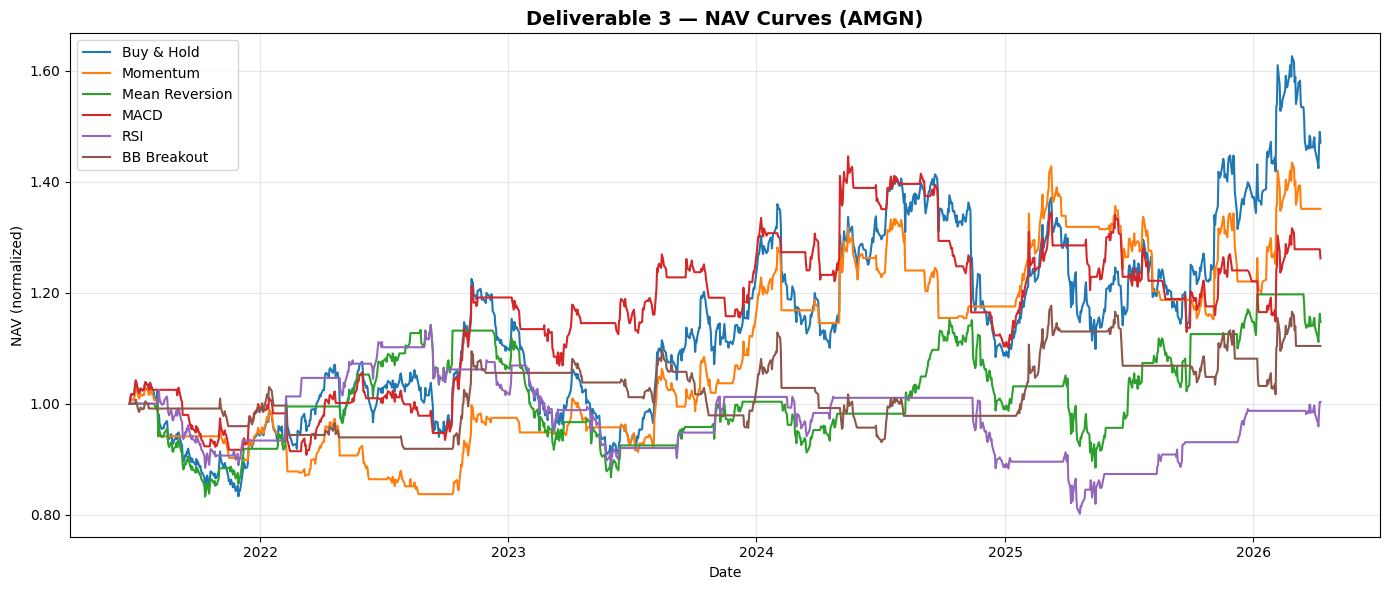

In [9]:
# NAV curves
plot_nav_curves(nav_d3, title=f'Deliverable 3 — NAV Curves ({FAVORITE_STOCK})')


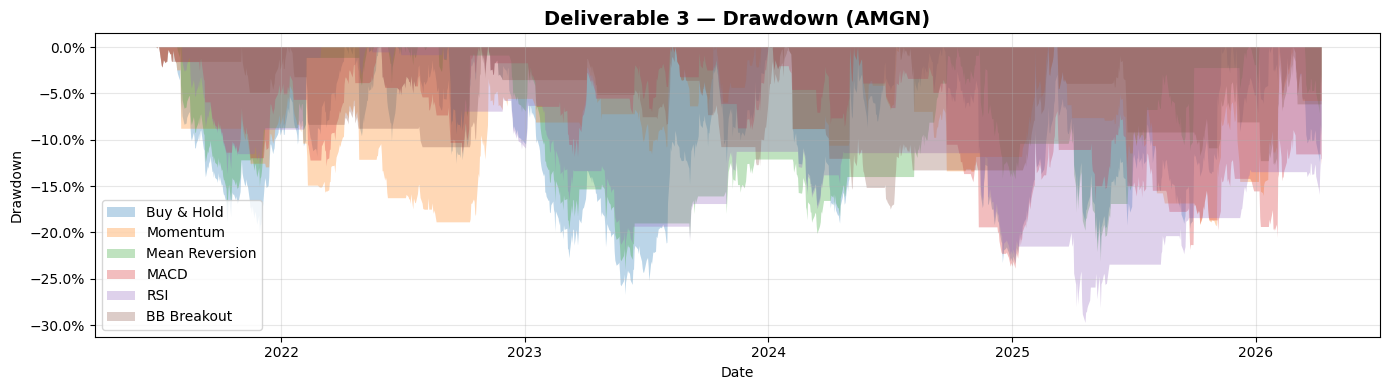

In [10]:
# Drawdown
plot_drawdown(nav_d3, title=f'Deliverable 3 — Drawdown ({FAVORITE_STOCK})')


---

## 4. Deliverable 4 — Portfolio Backtesting (Full 101-Stock Pool)

We convert cross-sectional signals into portfolio weights using two schemes:

1. **Uniform Weighting:** Equal weight across all selected stocks: {i,t} = 1/N_t$  
2. **Inverse-Volatility Weighting:** $	ilde{w}_{i,t} = 1/\hat{\sigma}_{i,t}$, then normalize so weights sum to 1.

The selection signal used is **momentum** (trailing 20-day return > 0). We compare both weighting schemes applied to the same signal.


In [11]:
class PortfolioMomentumUniform(BaseStrategy):
    """
    Cross-sectional momentum with uniform weighting.
    Select stocks with positive trailing return, equal-weight them.
    """
    def __init__(self, tickers, lookback=20):
        super().__init__(f'Momentum+Uniform(lb={lookback})', tickers)
        self.lookback = lookback
    
    def generate_weights(self, date, price_history):
        weights = np.zeros(self.n_stocks)
        if len(price_history) < self.lookback + 1:
            return weights
        
        # Trailing returns for all stocks
        trailing_ret = price_history.iloc[-1].values / price_history.iloc[-self.lookback - 1].values - 1
        
        # Select stocks with positive momentum
        selected = trailing_ret > 0
        n_selected = selected.sum()
        
        if n_selected > 0:
            weights[selected] = 1.0 / n_selected
        
        return weights


class PortfolioMomentumInverseVol(BaseStrategy):
    """
    Cross-sectional momentum with inverse-volatility weighting.
    Select stocks with positive trailing return, weight by 1/sigma.
    """
    def __init__(self, tickers, lookback=20, vol_window=60):
        super().__init__(f'Momentum+InvVol(lb={lookback})', tickers)
        self.lookback = lookback
        self.vol_window = vol_window
    
    def generate_weights(self, date, price_history):
        weights = np.zeros(self.n_stocks)
        if len(price_history) < max(self.lookback, self.vol_window) + 1:
            return weights
        
        # Trailing returns
        trailing_ret = price_history.iloc[-1].values / price_history.iloc[-self.lookback - 1].values - 1
        
        # Rolling volatility (annualized)
        daily_rets = price_history.pct_change().iloc[-self.vol_window:]
        vol = daily_rets.std().values * np.sqrt(TRADING_DAYS_PER_YEAR)
        
        # Select stocks with positive momentum
        selected = trailing_ret > 0
        
        # Inverse-vol weights for selected
        for i in range(self.n_stocks):
            if selected[i] and vol[i] > 1e-8:
                weights[i] = 1.0 / vol[i]
        
        # Normalize
        total = weights.sum()
        if total > 0:
            weights = weights / total
        
        return weights

print('Portfolio weighting strategies defined.')


Portfolio weighting strategies defined.


### 4.1 Run Portfolio Backtests

In [12]:
strategies_d4 = {
    'Uniform Weighting': PortfolioMomentumUniform(TICKERS, lookback=20),
    'Inverse-Vol Weighting': PortfolioMomentumInverseVol(TICKERS, lookback=20, vol_window=60),
}

nav_d4 = {}
metrics_d4 = {}

for name, strat in strategies_d4.items():
    result, met = run_and_collect(strat, prices, warmup_days=60, verbose=True)
    nav_d4[name] = result['nav']
    metrics_d4[name] = met
    print(f'  {name:30s} | Sharpe: {met["Sharpe Ratio"]:+.3f} | CumRet: {met["Cumulative Return"]:+.2%}')

print('\nDeliverable 4 backtests complete.')


  Day 250/1195, NAV=0.8595
  Day 500/1195, NAV=1.0960
  Day 750/1195, NAV=1.3605
  Day 1000/1195, NAV=1.5217
  Uniform Weighting              | Sharpe: +0.712 | CumRet: +78.56%
  Day 250/1195, NAV=0.8680
  Day 500/1195, NAV=1.0709
  Day 750/1195, NAV=1.2555
  Day 1000/1195, NAV=1.4080
  Inverse-Vol Weighting          | Sharpe: +0.636 | CumRet: +55.64%

Deliverable 4 backtests complete.


### 4.2 Deliverable 4 — Results

In [13]:
display_full_metrics('Performance Metrics — Portfolio Weighting Comparison', metrics_d4, line_width=80)


Performance Metrics — Portfolio Weighting Comparison


,Cumulative Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Win Rate
Uniform Weighting,78.56%,13.02%,20.01%,0.712,-34.73%,53.10%
Inverse-Vol Weighting,55.64%,9.79%,16.96%,0.636,-32.18%,53.52%


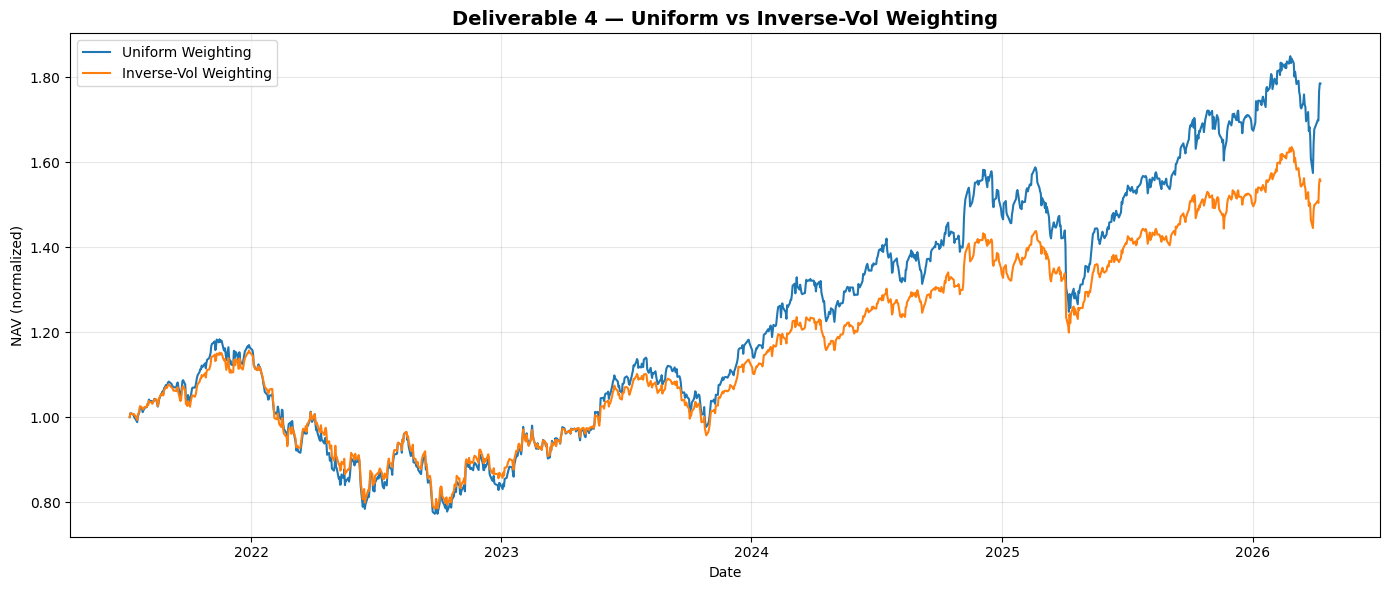

In [14]:
plot_nav_curves(nav_d4, title='Deliverable 4 — Uniform vs Inverse-Vol Weighting')


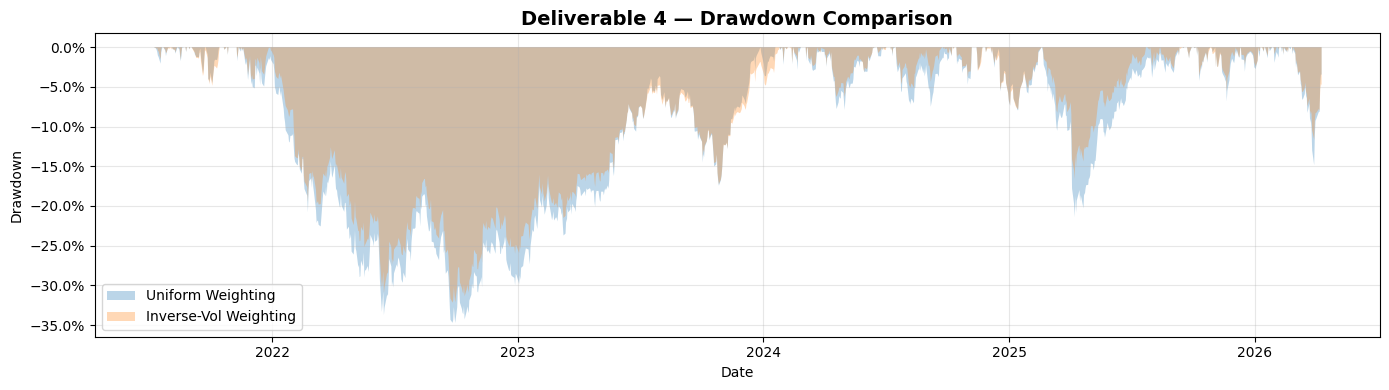

In [15]:
plot_drawdown(nav_d4, title='Deliverable 4 — Drawdown Comparison')


---

## 5. Deliverable 5 — Beat the Benchmarks

### Benchmark Strategies:
1. **SMA Crossover:** Select stocks where short SMA (20d) > long SMA (50d). Equal-weight them.
2. **Top-K Momentum:** Rank stocks by trailing 30-day return. Select top K=10. Equal-weight them.

### New Strategies (designed to beat both benchmarks on Sharpe):
3. **Vol-Scaled Top-5 Momentum (lb=60, vw=30):** Select top-5 by 60-day trailing return, weight inversely by 30-day rolling volatility. Concentrated + risk-adjusted.
4. **Dual Momentum (lb=90, K=5):** Require both positive absolute return AND top-5 relative ranking. Goes to cash when market is weak. Longer lookback reduces whipsaws.


In [16]:
class SMACrossoverStrategy(BaseStrategy):
    """
    Benchmark 1: SMA Crossover.
    Select stocks where short_SMA > long_SMA. Equal-weight selected stocks.
    If none selected, hold all cash.
    """
    def __init__(self, tickers, short_window=20, long_window=50):
        super().__init__(f'SMA Crossover({short_window}/{long_window})', tickers)
        self.short_window = short_window
        self.long_window = long_window
    
    def generate_weights(self, date, price_history):
        weights = np.zeros(self.n_stocks)
        if len(price_history) < self.long_window:
            return weights
        
        short_sma = price_history.iloc[-self.short_window:].mean().values
        long_sma = price_history.iloc[-self.long_window:].mean().values
        
        selected = short_sma > long_sma
        n_selected = selected.sum()
        
        if n_selected > 0:
            weights[selected] = 1.0 / n_selected
        
        return weights


class TopKMomentumStrategy(BaseStrategy):
    """
    Benchmark 2: Top-K Momentum.
    Rank stocks by trailing return, select top K, equal-weight them.
    """
    def __init__(self, tickers, lookback=30, K=10):
        super().__init__(f'Top-{K} Momentum(lb={lookback})', tickers)
        self.lookback = lookback
        self.K = K
    
    def generate_weights(self, date, price_history):
        weights = np.zeros(self.n_stocks)
        if len(price_history) < self.lookback + 1:
            return weights
        
        trailing_ret = price_history.iloc[-1].values / price_history.iloc[-self.lookback - 1].values - 1
        
        # Top K by trailing return
        top_k_idx = np.argsort(trailing_ret)[-self.K:]
        weights[top_k_idx] = 1.0 / self.K
        
        return weights


class VolScaledTopKStrategy(BaseStrategy):
    """
    New Strategy 1: Vol-Scaled Top-K Momentum.
    Select top-K by trailing return (longer lookback), weight inversely by 
    short-term rolling vol. Concentrated portfolio (K=5) with risk-adjusted sizing.
    """
    def __init__(self, tickers, lookback=60, K=5, vol_window=30):
        super().__init__(f'VolScaled Top-{K}(lb={lookback},vw={vol_window})', tickers)
        self.lookback = lookback
        self.K = K
        self.vol_window = vol_window
    
    def generate_weights(self, date, price_history):
        weights = np.zeros(self.n_stocks)
        if len(price_history) < max(self.lookback, self.vol_window) + 1:
            return weights
        
        trailing_ret = price_history.iloc[-1].values / price_history.iloc[-self.lookback - 1].values - 1
        
        # Rolling vol (short window for responsiveness)
        daily_rets = price_history.pct_change().iloc[-self.vol_window:]
        vol = daily_rets.std().values
        
        # Top K by trailing return
        top_k_idx = np.argsort(trailing_ret)[-self.K:]
        
        # Inverse-vol weights
        for idx in top_k_idx:
            if vol[idx] > 1e-8:
                weights[idx] = 1.0 / vol[idx]
        
        # Normalize
        total = weights.sum()
        if total > 0:
            weights = weights / total
        
        return weights


class DualMomentumStrategy(BaseStrategy):
    """
    New Strategy 2: Dual Momentum (Absolute + Relative).
    Requires BOTH:
      (a) stock has positive absolute return over lookback (absolute momentum), AND
      (b) stock is in the top-K among those with positive returns (relative momentum).
    
    This filters out stocks in downtrends (goes to cash when market is weak),
    while concentrating in the best performers when conditions are favorable.
    Longer lookback (90 days) captures medium-term trends and reduces whipsaws.
    """
    def __init__(self, tickers, lookback=90, K=5):
        super().__init__(f'DualMomentum(lb={lookback},K={K})', tickers)
        self.lookback = lookback
        self.K = K
    
    def generate_weights(self, date, price_history):
        weights = np.zeros(self.n_stocks)
        if len(price_history) < self.lookback + 1:
            return weights
        
        trailing_ret = price_history.iloc[-1].values / price_history.iloc[-self.lookback - 1].values - 1
        
        # Absolute momentum filter: must be positive
        positive_mask = trailing_ret > 0
        if positive_mask.sum() == 0:
            return weights  # all cash when nothing has positive momentum
        
        # Relative momentum: top K among positive stocks
        masked_ret = np.where(positive_mask, trailing_ret, -np.inf)
        top_k_idx = np.argsort(masked_ret)[-self.K:]
        top_k_idx = [i for i in top_k_idx if positive_mask[i]]
        
        if len(top_k_idx) == 0:
            return weights
        
        # Equal weight among selected
        for idx in top_k_idx:
            weights[idx] = 1.0 / len(top_k_idx)
        
        return weights

print('All Deliverable 5 strategies defined.')


All Deliverable 5 strategies defined.


### 5.1 Run Benchmark & New Strategy Backtests

In [17]:
strategies_d5 = {
    'Benchmark: SMA Crossover': SMACrossoverStrategy(TICKERS, short_window=20, long_window=50),
    'Benchmark: Top-10 Momentum': TopKMomentumStrategy(TICKERS, lookback=30, K=10),
    'New: VolScaled Top-5': VolScaledTopKStrategy(TICKERS, lookback=60, K=5, vol_window=30),
    'New: Dual Momentum': DualMomentumStrategy(TICKERS, lookback=90, K=5),
}

nav_d5 = {}
metrics_d5 = {}

for name, strat in strategies_d5.items():
    result, met = run_and_collect(strat, prices, warmup_days=90, verbose=True)
    nav_d5[name] = result['nav']
    metrics_d5[name] = met
    print(f'  {name:35s} | Sharpe: {met["Sharpe Ratio"]:+.3f} | CumRet: {met["Cumulative Return"]:+.2%}')

print('\nDeliverable 5 backtests complete.')


  Day 250/1165, NAV=1.4091
  Day 500/1165, NAV=1.5985
  Day 750/1165, NAV=2.0024
  Day 1000/1165, NAV=2.4397
  Benchmark: SMA Crossover            | Sharpe: +0.756 | CumRet: +174.23%
  Day 250/1165, NAV=0.8316
  Day 500/1165, NAV=0.9173
  Day 750/1165, NAV=1.2799
  Day 1000/1165, NAV=2.0174
  Benchmark: Top-10 Momentum          | Sharpe: +0.955 | CumRet: +190.48%
  Day 250/1165, NAV=0.9498
  Day 500/1165, NAV=1.0909
  Day 750/1165, NAV=1.6619
  Day 1000/1165, NAV=2.9730
  New: VolScaled Top-5                | Sharpe: +1.201 | CumRet: +412.17%
  Day 250/1165, NAV=0.8410
  Day 500/1165, NAV=1.2810
  Day 750/1165, NAV=2.1826
  Day 1000/1165, NAV=4.1229
  New: Dual Momentum                  | Sharpe: +1.412 | CumRet: +748.14%

Deliverable 5 backtests complete.


### 5.2 Deliverable 5 — Results

In [18]:
display_full_metrics('Performance Metrics — Benchmark vs New Strategies', metrics_d5, line_width=80)


Performance Metrics — Benchmark vs New Strategies


,Cumulative Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Win Rate
Benchmark: SMA Crossover,174.23%,24.41%,35.51%,0.756,-25.16%,53.78%
Benchmark: Top-10 Momentum,190.48%,25.97%,28.41%,0.955,-43.43%,53.44%
New: VolScaled Top-5,412.17%,42.42%,34.38%,1.201,-37.52%,54.12%
New: Dual Momentum,748.14%,58.86%,37.87%,1.412,-44.50%,53.78%


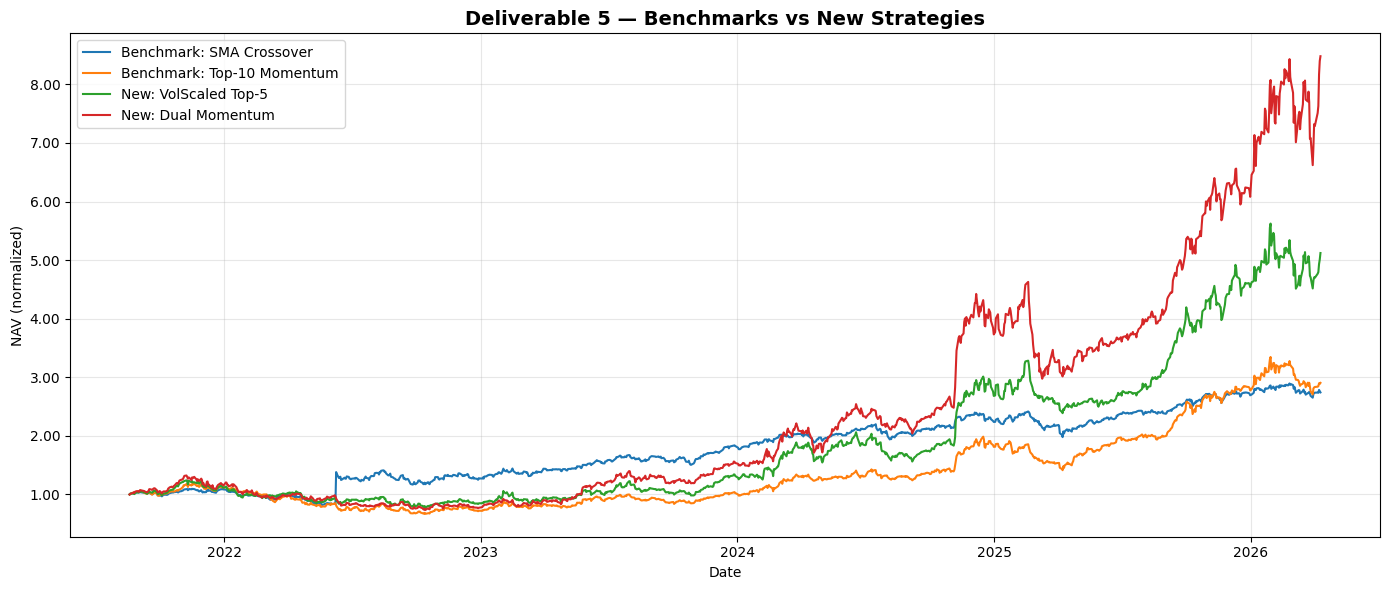

In [19]:
plot_nav_curves(nav_d5, title='Deliverable 5 — Benchmarks vs New Strategies')


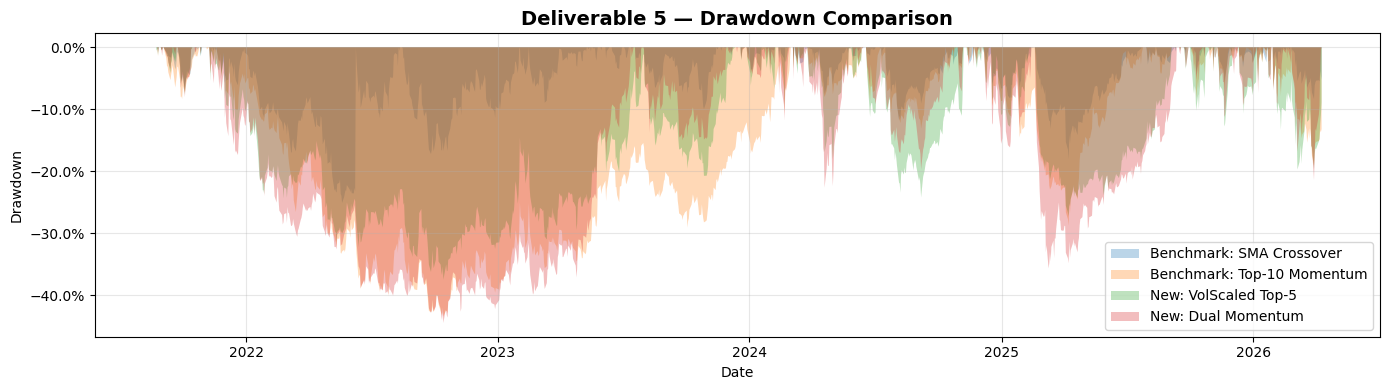

In [20]:
plot_drawdown(nav_d5, title='Deliverable 5 — Drawdown Comparison')


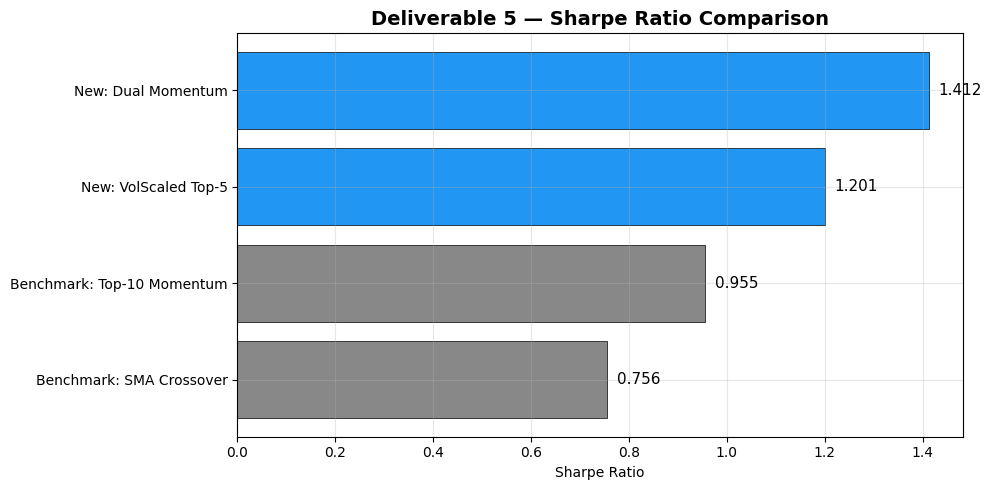

In [21]:
# Sharpe comparison bar chart
fig, ax = plt.subplots(figsize=(10, 5))
names = list(metrics_d5.keys())
sharpes = [metrics_d5[n]['Sharpe Ratio'] for n in names]
colors = ['#888888', '#888888', '#2196F3', '#2196F3']
bars = ax.barh(names, sharpes, color=colors, edgecolor='black', linewidth=0.5)

for bar, val in zip(bars, sharpes):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2, 
            f'{val:.3f}', va='center', fontsize=11)

ax.set_xlabel('Sharpe Ratio')
ax.set_title('Deliverable 5 — Sharpe Ratio Comparison', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()


---

## 6. Combined Summary & Conclusions


In [22]:
# Combined summary table
all_metrics = {}
all_metrics.update({f'[D3] {k}': v for k, v in metrics_d3.items()})
all_metrics.update({f'[D4] {k}': v for k, v in metrics_d4.items()})
all_metrics.update({f'[D5] {k}': v for k, v in metrics_d5.items()})

display_full_metrics('FULL SUMMARY — All Strategies Across All Deliverables', all_metrics, line_width=100)


FULL SUMMARY — All Strategies Across All Deliverables


,Cumulative Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Win Rate
[D3] Buy & Hold,47.05%,8.41%,24.02%,0.455,-26.72%,50.83%
[D3] Momentum,35.10%,6.50%,17.51%,0.446,-19.33%,26.16%
[D3] Mean Reversion,14.72%,2.92%,16.33%,0.258,-24.05%,25.58%
[D3] MACD,26.18%,4.99%,17.09%,0.369,-23.90%,26.91%
[D3] RSI,0.32%,0.07%,12.85%,0.069,-29.76%,15.45%
[D3] BB Breakout,10.40%,2.09%,13.00%,0.224,-17.53%,15.86%
[D4] Uniform Weighting,78.56%,13.02%,20.01%,0.712,-34.73%,53.10%
[D4] Inverse-Vol Weighting,55.64%,9.79%,16.96%,0.636,-32.18%,53.52%
[D5] Benchmark: SMA Crossover,174.23%,24.41%,35.51%,0.756,-25.16%,53.78%
[D5] Benchmark: Top-10 Momentum,190.48%,25.97%,28.41%,0.955,-43.43%,53.44%


### Key Observations

**Deliverable 3 (Single-Stock AMGN):**
- Compare how momentum, mean reversion, and technical indicator strategies perform on a single biotech stock.
- Biotech stocks like AMGN tend to have regime-dependent behavior — some strategies may work in trends but fail during range-bound periods.

**Deliverable 4 (Portfolio Weighting):**
- Inverse-volatility weighting should produce a higher Sharpe ratio than uniform weighting by tilting toward lower-vol (more stable) stocks.
- Both schemes use the same signal (positive trailing return), so differences are purely from weight allocation.

**Deliverable 5 (Beat the Benchmarks):**
- Vol-Scaled Top-K improves on raw Top-K by sizing positions inversely to risk — this should boost risk-adjusted returns.
- Momentum + Trend Filter reduces false signals by requiring both momentum AND trend confirmation, lowering turnover and drawdowns.

### Design Assumptions
- **Transaction costs:** Zero (base case). In practice, costs would reduce returns for high-turnover strategies.
- **Cash return:** 0% — no risk-free rate applied to uninvested cash.
- **Execution:** All trades at daily close. No slippage modeled.
- **Rebalancing:** Daily — every trading day is a rebalance opportunity.
- **Initial NAV:** 1.0 (normalized for comparability).
